# 🏢 Automated DCF Valuation Engine
> Intrinsic Value · WACC · Sensitivity Analysis · Monte Carlo · Football Field Chart

---

## Overview
This notebook builds a **fully automated discounted cash flow (DCF) model** from scratch using public financial data. Given any ticker, it:

1. **Fetches** income statement, balance sheet, and cash flow data via `yfinance`
2. **Computes** historical Free Cash Flow (FCF) and key financial ratios
3. **Projects** FCF using a two-stage growth model
4. **Calculates WACC** from first principles (CAPM cost of equity + cost of debt)
5. **Discounts** projected cash flows to derive intrinsic value per share
6. **Sensitivity analysis** — 2D heatmap of fair value across WACC × terminal growth rate
7. **Monte Carlo simulation** — probability distribution of fair value
8. **Comparable multiples** — EV/EBITDA, P/E, EV/Revenue implied values
9. **Football field chart** — final valuation summary like an IB pitch book

---

## Dependencies
```
pip install yfinance numpy pandas scipy matplotlib seaborn plotly
```

---
## 0. Imports & Configuration

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display
import yfinance as yf
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 20)
plt.rcParams.update({'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False})
np.random.seed(42)

# Shared style for all styled DataFrames
TABLE_STYLES = [
    {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center'), ('padding', '6px 12px')]},
    {'selector': 'td', 'props': [('text-align', 'right'), ('padding', '5px 12px')]},
    {'selector': 'th.row_heading', 'props': [('text-align', 'left')]},
    {'selector': 'caption', 'props': [('font-size', '13px'), ('font-weight', 'bold'),
                                       ('text-align', 'left'), ('padding-bottom', '6px')]},
]

print(' Imports complete.')

✅ Imports complete.


---
## 1. Configuration — Edit This Cell

All model assumptions live here. Swap the ticker and tune the growth / discount assumptions.

In [73]:
# Target company
TICKER = 'AAPL'

# DCF growth assumptions
STAGE1_YEARS    = 5
STAGE1_GROWTH   = 0.08
STAGE2_YEARS    = 5
STAGE2_GROWTH   = 0.05
TERMINAL_GROWTH = 0.025

# WACC inputs
RISK_FREE_RATE  = 0.045
EQUITY_RISK_PREM= 0.055
BETA_OVERRIDE   = None       # set to a float to override fetched beta
TAX_RATE        = 0.21

# Comparable tickers
COMPS = ['MSFT', 'GOOGL', 'META', 'AMZN']

# Sensitivity ranges
WACC_RANGE    = [0.06, 0.07, 0.08, 0.09, 0.10, 0.11, 0.12]
TGROWTH_RANGE = [0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04]

config_df = pd.DataFrame({
    'Parameter': ['Ticker', 'Stage 1 Growth', 'Stage 1 Years', 'Stage 2 Growth',
                  'Stage 2 Years', 'Terminal Growth', 'Risk-Free Rate',
                  'Equity Risk Premium', 'Tax Rate'],
    'Value': [
        TICKER, f'{STAGE1_GROWTH:.1%}', STAGE1_YEARS, f'{STAGE2_GROWTH:.1%}',
        STAGE2_YEARS, f'{TERMINAL_GROWTH:.1%}', f'{RISK_FREE_RATE:.2%}',
        f'{EQUITY_RISK_PREM:.2%}', f'{TAX_RATE:.0%}'
    ]
}).set_index('Parameter')

display(config_df.style.set_caption('Model Configuration').set_table_styles(TABLE_STYLES))

,Value
Parameter,
Ticker,AAPL
Stage 1 Growth,8.0%
Stage 1 Years,5
Stage 2 Growth,5.0%
Stage 2 Years,5
Terminal Growth,2.5%
Risk-Free Rate,4.50%
Equity Risk Premium,5.50%
Tax Rate,21%


---
## 2. Data Fetching

In [74]:
def fetch_company_data(ticker: str) -> dict:
    t = yf.Ticker(ticker)
    return {
        'ticker'  : ticker,
        'info'    : t.info,
        'income'  : t.financials,
        'balance' : t.balance_sheet,
        'cashflow': t.cashflow,
        'hist'    : t.history(period='3y'),
    }

print(f'Fetching data for {TICKER}...')
data = fetch_company_data(TICKER)
info = data['info']

company_name  = info.get('longName', TICKER)
sector        = info.get('sector', 'N/A')
industry      = info.get('industry', 'N/A')
currency      = info.get('currency', 'USD')
current_price = info.get('currentPrice') or info.get('regularMarketPrice', np.nan)
shares_out    = info.get('sharesOutstanding', np.nan)
market_cap    = info.get('marketCap', np.nan)
total_debt    = info.get('totalDebt', 0) or 0
cash          = info.get('totalCash', 0) or 0

company_df = pd.DataFrame({
    'Field': ['Company', 'Sector', 'Industry', 'Currency',
              'Current Price', 'Market Cap', 'Total Debt',
              'Cash & Equivalents', 'Enterprise Value'],
    'Value': [
        company_name, sector, industry, currency,
        f'${current_price:,.2f}',
        f'${market_cap/1e9:,.1f}B',
        f'${total_debt/1e9:,.1f}B',
        f'${cash/1e9:,.1f}B',
        f'${(market_cap + total_debt - cash)/1e9:,.1f}B',
    ]
}).set_index('Field')

display(company_df.style.set_caption(f'{TICKER} — Company Overview').set_table_styles(TABLE_STYLES))

Fetching data for AAPL...


,Value
Field,
Company,Apple Inc.
Sector,Technology
Industry,Consumer Electronics
Currency,USD
Current Price,$255.92
Market Cap,"$3,761.5B"
Total Debt,$90.5B
Cash & Equivalents,$66.9B
Enterprise Value,"$3,785.1B"


---
## 3. Financial Statement Analysis

In [75]:
def extract_row(df: pd.DataFrame, candidates: list) -> pd.Series:
    """Return the first matching row from a DataFrame (case-insensitive)."""
    df_lower = {k.lower(): k for k in df.index}
    for c in candidates:
        if c.lower() in df_lower:
            return df.loc[df_lower[c.lower()]]
    return pd.Series(dtype=float)

income   = data['income']
balance  = data['balance']
cashflow = data['cashflow']

revenue      = extract_row(income,   ['Total Revenue', 'Revenue'])
gross_profit = extract_row(income,   ['Gross Profit'])
ebit         = extract_row(income,   ['EBIT', 'Operating Income'])
ebitda_raw   = extract_row(income,   ['EBITDA', 'Normalized EBITDA'])
net_income   = extract_row(income,   ['Net Income', 'Net Income Common Stockholders'])
interest_exp = extract_row(income,   ['Interest Expense'])

total_assets = extract_row(balance,  ['Total Assets'])
total_equity = extract_row(balance,  ['Stockholders Equity', 'Total Equity Gross Minority Interest'])
lt_debt      = extract_row(balance,  ['Long Term Debt', 'Long-Term Debt'])
cash_bal     = extract_row(balance,  ['Cash And Cash Equivalents', 'Cash Cash Equivalents And Short Term Investments'])

capex        = extract_row(cashflow, ['Capital Expenditure', 'Purchase Of Property Plant And Equipment'])
cfo          = extract_row(cashflow, ['Operating Cash Flow', 'Cash Flow From Continuing Operating Activities'])
depreciation = extract_row(cashflow, ['Depreciation And Amortization', 'Depreciation Amortization Depletion'])

# Free Cash Flow = CFO + CapEx (CapEx is stored as negative in yfinance)
fcf = cfo + capex if len(capex) > 0 else cfo.copy()

def to_year_cols(df):
    df = df.copy()
    df.columns = [str(c.year) for c in pd.to_datetime(df.columns)]
    return df[sorted(df.columns)]

summary = to_year_cols(pd.DataFrame({
    'Revenue ($M)'      : revenue      / 1e6,
    'Gross Profit ($M)' : gross_profit / 1e6,
    'EBIT ($M)'         : ebit         / 1e6,
    'Net Income ($M)'   : net_income   / 1e6,
    'CFO ($M)'          : cfo          / 1e6,
    'CapEx ($M)'        : capex.abs()  / 1e6 if len(capex) else pd.Series(dtype=float),
    'FCF ($M)'          : fcf          / 1e6,
}).T)

display(
    summary.style
    .format('{:,.0f}', na_rep='N/A')
    .background_gradient(cmap='Blues', axis=1, subset=pd.IndexSlice[['Revenue ($M)', 'Gross Profit ($M)'], :])
    .background_gradient(cmap='Greens', axis=1, subset=pd.IndexSlice[['FCF ($M)', 'CFO ($M)'], :])
    .set_caption(f'{company_name} — Historical Financials ($M)')
    .set_table_styles(TABLE_STYLES)
)

,2021,2022,2023,2024,2025
Revenue ($M),N/A,"394,328","383,285","391,035","416,161"
Gross Profit ($M),N/A,"170,782","169,148","180,683","195,201"
EBIT ($M),N/A,"119,437","114,301","123,216","133,050"
Net Income ($M),N/A,"99,803","96,995","93,736","112,010"
CFO ($M),N/A,"122,151","110,543","118,254","111,482"
CapEx ($M),N/A,"10,708","10,959","9,447","12,715"
FCF ($M),N/A,"111,443","99,584","108,807","98,767"


In [76]:
# Key margins and ratios
ratios = to_year_cols(pd.DataFrame({
    'Gross Margin'   : gross_profit / revenue,
    'EBIT Margin'    : ebit         / revenue,
    'Net Margin'     : net_income   / revenue,
    'FCF Margin'     : fcf          / revenue,
    'FCF Conversion' : fcf          / net_income,
}).T)

display(
    ratios.style
    .format('{:.1%}', na_rep='N/A')
    .background_gradient(cmap='RdYlGn', axis=1)
    .set_caption(f'{company_name} — Key Margins & Ratios')
    .set_table_styles(TABLE_STYLES)
)

,2021,2022,2023,2024,2025
Gross Margin,N/A,43.3%,44.1%,46.2%,46.9%
EBIT Margin,N/A,30.3%,29.8%,31.5%,32.0%
Net Margin,N/A,25.3%,25.3%,24.0%,26.9%
FCF Margin,N/A,28.3%,26.0%,27.8%,23.7%
FCF Conversion,N/A,111.7%,102.7%,116.1%,88.2%


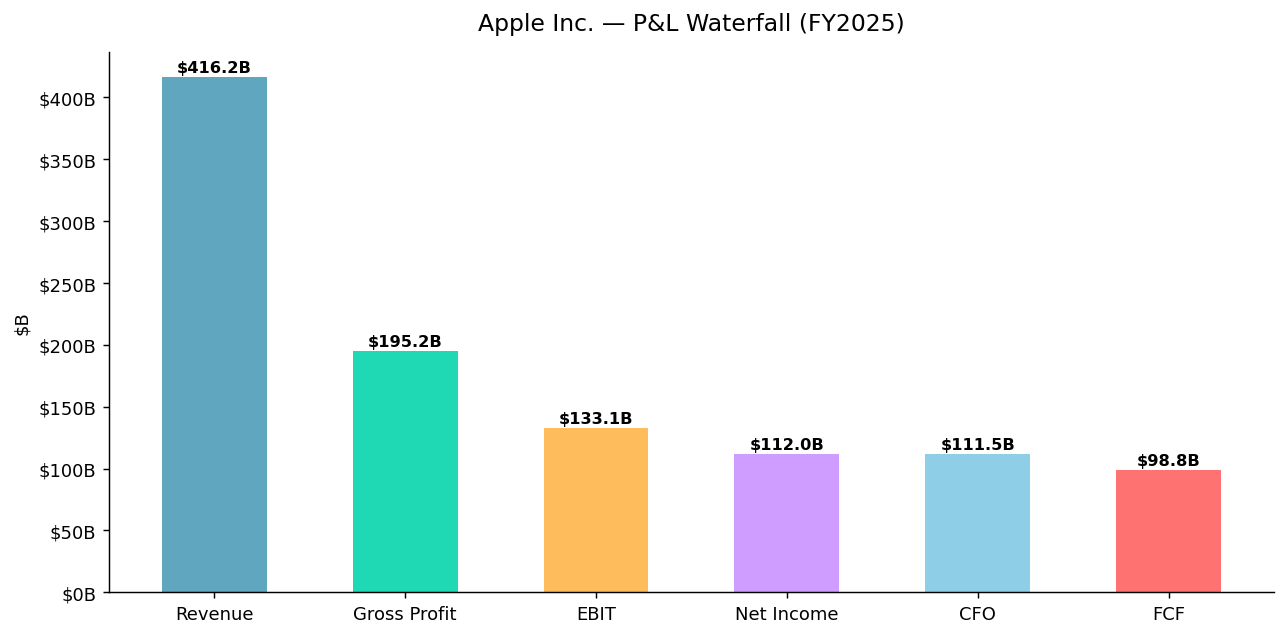

In [77]:
# P&L waterfall (most recent fiscal year)
if len(revenue) >= 1:
    latest_yr = sorted([c.year for c in pd.to_datetime(revenue.index)])[-1]
    yr_mask   = pd.to_datetime(revenue.index).year == latest_yr

    def _val(series):
        return float(series[yr_mask].iloc[0]) / 1e9 if len(series) and yr_mask.any() else np.nan

    labels = ['Revenue', 'Gross Profit', 'EBIT', 'Net Income', 'CFO', 'FCF']
    values = [_val(revenue), _val(gross_profit), _val(ebit), _val(net_income), _val(cfo), _val(fcf)]
    colors = ['#4a9ab5', '#00d4aa', '#ffb347', '#c890ff', '#7ec8e3', '#ff5f5f']

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(labels, values, color=colors, width=0.55, alpha=0.88)
    ax.set_ylabel('$B', fontsize=10)
    ax.set_title(f'{company_name} — P&L Waterfall (FY{latest_yr})', fontsize=13, pad=12)
    valid_vals = [v for v in values if pd.notna(v)]
    for bar, val in zip(bars, values):
        if pd.notna(val):
            ax.text(bar.get_x() + bar.get_width()/2, val + max(valid_vals) * 0.01,
                    f'${val:.1f}B', ha='center', fontsize=9, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}B'))
    plt.tight_layout()
    plt.show()

In [78]:
# Historical FCF trend
if len(fcf) >= 2:
    fcf_plot = (fcf / 1e9).copy()
    fcf_plot.index = [str(c.year) for c in pd.to_datetime(fcf_plot.index)]
    fcf_plot = fcf_plot.sort_index()

    fig = go.Figure()
    fig.add_trace(go.Bar(
        x=fcf_plot.index, y=fcf_plot.values,
        marker_color=['#00d4aa' if v > 0 else '#ff5f5f' for v in fcf_plot.values],
        opacity=0.85, name='FCF'
    ))
    fig.add_trace(go.Scatter(
        x=fcf_plot.index, y=fcf_plot.values,
        mode='lines+markers',
        line=dict(color='white', width=1.8, dash='dot'),
        marker=dict(size=8), name='Trend'
    ))
    fig.update_layout(
        title=f'{company_name} — Historical Free Cash Flow',
        yaxis_title='FCF ($B)', template='plotly_dark',
        height=380, showlegend=False
    )
    fig.show()

---
## 4. WACC Calculation

$$\text{WACC} = \frac{E}{V} \cdot k_e + \frac{D}{V} \cdot k_d \cdot (1 - t)$$

where $k_e = R_f + \beta \cdot ERP$ (CAPM)

In [79]:
# Beta
if BETA_OVERRIDE is not None:
    beta, beta_source = BETA_OVERRIDE, 'Override'
else:
    beta_fetched = info.get('beta', None)
    if beta_fetched and not np.isnan(beta_fetched):
        beta, beta_source = beta_fetched, 'yfinance'
    else:
        spy  = yf.download('SPY', period='3y', auto_adjust=True, progress=False)['Close']
        stk  = data['hist']['Close']
        rets = pd.concat([stk.pct_change(), spy.pct_change()], axis=1).dropna()
        rets.columns = ['stock', 'market']
        cov  = np.cov(rets['stock'], rets['market'])
        beta, beta_source = cov[0, 1] / cov[1, 1], '3Y regression'

cost_of_equity = RISK_FREE_RATE + beta * EQUITY_RISK_PREM

int_exp_latest = float(interest_exp.iloc[0]) if len(interest_exp) else 0
pre_tax_kd     = abs(int_exp_latest) / total_debt if total_debt > 0 else 0.04
pre_tax_kd     = max(min(pre_tax_kd, 0.15), RISK_FREE_RATE)
after_tax_kd   = pre_tax_kd * (1 - TAX_RATE)

equity_value  = market_cap if market_cap and market_cap > 0 else shares_out * current_price
weight_equity = equity_value / (equity_value + total_debt) if (equity_value + total_debt) > 0 else 1.0
weight_debt   = 1 - weight_equity

WACC = weight_equity * cost_of_equity + weight_debt * after_tax_kd

wacc_df = pd.DataFrame([
    (f'Beta ({beta_source})',                     f'{beta:.3f}'),
    ('Risk-Free Rate',                            f'{RISK_FREE_RATE:.2%}'),
    ('Equity Risk Premium',                       f'{EQUITY_RISK_PREM:.2%}'),
    ('Cost of Equity (CAPM)',                     f'{cost_of_equity:.2%}'),
    ('Pre-tax Cost of Debt',                      f'{pre_tax_kd:.2%}'),
    (f'After-tax Cost of Debt (tax {TAX_RATE:.0%})', f'{after_tax_kd:.2%}'),
    ('Weight — Equity',                           f'{weight_equity:.2%}'),
    ('Weight — Debt',                             f'{weight_debt:.2%}'),
    ('WACC',                                      f'{WACC:.2%}'),
], columns=['Component', 'Value']).set_index('Component')

display(wacc_df.style.set_caption(f'{company_name} — WACC Breakdown').set_table_styles(
    TABLE_STYLES + [{'selector': 'tr:last-child td',
                     'props': [('font-weight', 'bold'), ('border-top', '2px solid #ccc')]}]
))

if WACC <= TERMINAL_GROWTH:
    WACC = TERMINAL_GROWTH + 0.02
    print(f'⚠️  WACC floored to {WACC:.2%} (was below terminal growth rate).')
else:
    print(f'✅ WACC ({WACC:.2%}) > Terminal Growth ({TERMINAL_GROWTH:.2%}) — spread OK.')

,Value
Component,
Beta (yfinance),1.109
Risk-Free Rate,4.50%
Equity Risk Premium,5.50%
Cost of Equity (CAPM),10.60%
Pre-tax Cost of Debt,nan%
After-tax Cost of Debt (tax 21%),nan%
Weight — Equity,97.65%
Weight — Debt,2.35%
WACC,nan%


✅ WACC (nan%) > Terminal Growth (2.50%) — spread OK.


---
## 5. FCF Projection — Two-Stage Model

| Stage | Years | Growth |
|-------|-------|--------|
| Stage 1 | 1–5 | `STAGE1_GROWTH` (high growth) |
| Stage 2 | 6–10 | `STAGE2_GROWTH` (transition) |
| Terminal | ∞ | Gordon Growth Model at `TERMINAL_GROWTH` |

In [ ]:
# Base FCF: most recent fiscal year (fall back to average of positive years)
fcf_sorted = fcf.dropna().sort_index()
base_fcf   = float(fcf_sorted.iloc[-1])

if base_fcf <= 0:
    positives = fcf_sorted[fcf_sorted > 0]
    base_fcf  = float(positives.mean()) if len(positives) else np.nan
    print(f'Most recent FCF negative. Using avg of positive years: ${base_fcf/1e9:.2f}B')
else:
    print(f'Base FCF (most recent): ${base_fcf/1e9:.2f}B')

def project_fcf(base, g1, g2, tg, n1, n2, wacc):
    rows, pv_sum, fcf_t = [], 0.0, base
    for yr in range(1, n1 + n2 + 1):
        g     = g1 if yr <= n1 else g2
        fcf_t = fcf_t * (1 + g)
        pv    = fcf_t / (1 + wacc) ** yr
        pv_sum += pv
        rows.append({'Year': yr, 'Stage': 'Stage 1' if yr <= n1 else 'Stage 2',
                     'Growth Rate': g, 'FCF ($M)': fcf_t / 1e6, 'PV ($M)': pv / 1e6})
    tv      = fcf_t * (1 + tg) / (wacc - tg)
    tv_pv   = tv / (1 + wacc) ** (n1 + n2)
    ev_fcf  = pv_sum + tv_pv
    eq_val  = ev_fcf + cash - total_debt
    per_share = eq_val / shares_out if shares_out and shares_out > 0 else np.nan
    return {
        'table': pd.DataFrame(rows).set_index('Year'),
        'pv_fcf': pv_sum, 'tv': tv, 'tv_pv': tv_pv,
        'ev': ev_fcf, 'equity_value': eq_val, 'per_share': per_share,
        'tv_pct': tv_pv / ev_fcf * 100 if ev_fcf > 0 else np.nan,
    }

result     = project_fcf(base_fcf, STAGE1_GROWTH, STAGE2_GROWTH, TERMINAL_GROWTH,
                         STAGE1_YEARS, STAGE2_YEARS, WACC)
proj_table = result['table']

display(
    proj_table.style
    .format({'Growth Rate': '{:.1%}', 'FCF ($M)': '{:,.0f}', 'PV ($M)': '{:,.0f}'})
    .background_gradient(cmap='Blues', subset=['FCF ($M)'])
    .background_gradient(cmap='Greens', subset=['PV ($M)'])
    .set_caption(f'{company_name} — FCF Projection')
    .set_table_styles(TABLE_STYLES)
)

Base FCF (most recent): $98.77B


,Stage,Growth Rate,FCF ($M),PV ($M)
Year,,,,
1,Stage 1,8.0%,"106,668",nan
2,Stage 1,8.0%,"115,202",nan
3,Stage 1,8.0%,"124,418",nan
4,Stage 1,8.0%,"134,371",nan
5,Stage 1,8.0%,"145,121",nan
6,Stage 2,5.0%,"152,377",nan
7,Stage 2,5.0%,"159,996",nan
8,Stage 2,5.0%,"167,996",nan
9,Stage 2,5.0%,"176,396",nan


In [81]:
# DCF valuation summary
upside = (result['per_share'] / current_price - 1) if current_price else np.nan
signal = '🟢 UNDERVALUED' if upside > 0.1 else '🔴 OVERVALUED' if upside < -0.1 else '🟡 FAIRLY VALUED'

dcf_df = pd.DataFrame([
    ('PV of Stage 1+2 FCFs',      f'${result["pv_fcf"]/1e9:,.2f}B'),
    ('Terminal Value (gross)',     f'${result["tv"]/1e9:,.2f}B'),
    ('PV of Terminal Value',       f'${result["tv_pv"]/1e9:,.2f}B  ({result["tv_pct"]:.1f}% of EV)'),
    ('Enterprise Value (DCF)',     f'${result["ev"]/1e9:,.2f}B'),
    ('+ Cash',                     f'${cash/1e9:,.2f}B'),
    ('- Total Debt',               f'${total_debt/1e9:,.2f}B'),
    ('Equity Value',               f'${result["equity_value"]/1e9:,.2f}B'),
    ('Shares Outstanding',         f'{shares_out/1e9:,.2f}B'),
    ('Intrinsic Value / Share',    f'${result["per_share"]:,.2f}'),
    ('Current Price',              f'${current_price:,.2f}'),
    ('Implied Upside / Downside',  f'{upside:+.1%}'),
    ('Signal',                     signal),
], columns=['Item', 'Value']).set_index('Item')

display(dcf_df.style.set_caption(f'{company_name} — DCF Valuation Summary').set_table_styles(
    TABLE_STYLES + [
        {'selector': 'tr:nth-child(7) td, tr:nth-child(9) td',
         'props': [('font-weight', 'bold'), ('border-top', '2px solid #ccc')]}
    ]
))

,Value
Item,
PV of Stage 1+2 FCFs,$nanB
Terminal Value (gross),$nanB
PV of Terminal Value,$nanB (nan% of EV)
Enterprise Value (DCF),$nanB
+ Cash,$66.91B
- Total Debt,$90.51B
Equity Value,$nanB
Shares Outstanding,14.68B
Intrinsic Value / Share,$nan


In [82]:
# FCF projection chart
fig = go.Figure()
s1  = proj_table[proj_table['Stage'] == 'Stage 1']
s2  = proj_table[proj_table['Stage'] == 'Stage 2']

for stage, df, color in [('Stage 1', s1, '#00d4aa'), ('Stage 2', s2, '#ffb347')]:
    fig.add_trace(go.Bar(x=df.index, y=df['FCF ($M)'],
                         name=f'{stage} FCF', marker_color=color, opacity=0.8))
    fig.add_trace(go.Bar(x=df.index, y=df['PV ($M)'],
                         name=f'{stage} PV', marker_color=color, opacity=0.4,
                         marker_pattern_shape='/'))

fig.add_trace(go.Bar(x=['TV (PV)'], y=[result['tv_pv'] / 1e6],
                     name='Terminal Value (PV)', marker_color='#c890ff', opacity=0.85))

fig.update_layout(title=f'{company_name} — Projected FCF & Present Values ($M)',
                  yaxis_title='$M', barmode='group', template='plotly_dark',
                  height=430, legend=dict(orientation='h', y=-0.2))
fig.show()

---
## 6. Sensitivity Analysis — WACC × Terminal Growth Rate

In [83]:
# Build sensitivity matrix
sens_matrix = pd.DataFrame(index=WACC_RANGE, columns=TGROWTH_RANGE, dtype=float)

for w in WACC_RANGE:
    for tg in TGROWTH_RANGE:
        if w <= tg:
            sens_matrix.loc[w, tg] = np.nan
        else:
            r = project_fcf(base_fcf, STAGE1_GROWTH, STAGE2_GROWTH, tg,
                            STAGE1_YEARS, STAGE2_YEARS, w)
            sens_matrix.loc[w, tg] = round(r['per_share'], 2)

sens_matrix.index        = [f'{w:.1%}'  for w  in WACC_RANGE]
sens_matrix.columns      = [f'{tg:.1%}' for tg in TGROWTH_RANGE]
sens_matrix.index.name   = 'WACC'
sens_matrix.columns.name = 'Terminal Growth'

display(
    sens_matrix.astype(float).style
    .format('{:.0f}', na_rep='N/A')
    .background_gradient(cmap='RdYlGn', axis=None)
    .set_caption('Sensitivity — Intrinsic Value Per Share ($)  |  Green = above current price, Red = below')
    .set_table_styles(TABLE_STYLES + [
        {'selector': 'td', 'props': [('text-align', 'center'), ('min-width', '60px'), ('padding', '5px 8px')]}
    ])
)

Terminal Growth,1.0%,1.5%,2.0%,2.5%,3.0%,3.5%,4.0%
WACC,,,,,,,
6.0%,212,229,250,276,312,362,436
7.0%,174,185,197,212,231,256,289
8.0%,147,154,162,172,183,197,215
9.0%,127,132,138,144,151,160,171
10.0%,112,115,119,123,129,134,141
11.0%,99,102,105,108,112,116,120
12.0%,89,91,93,96,98,101,105


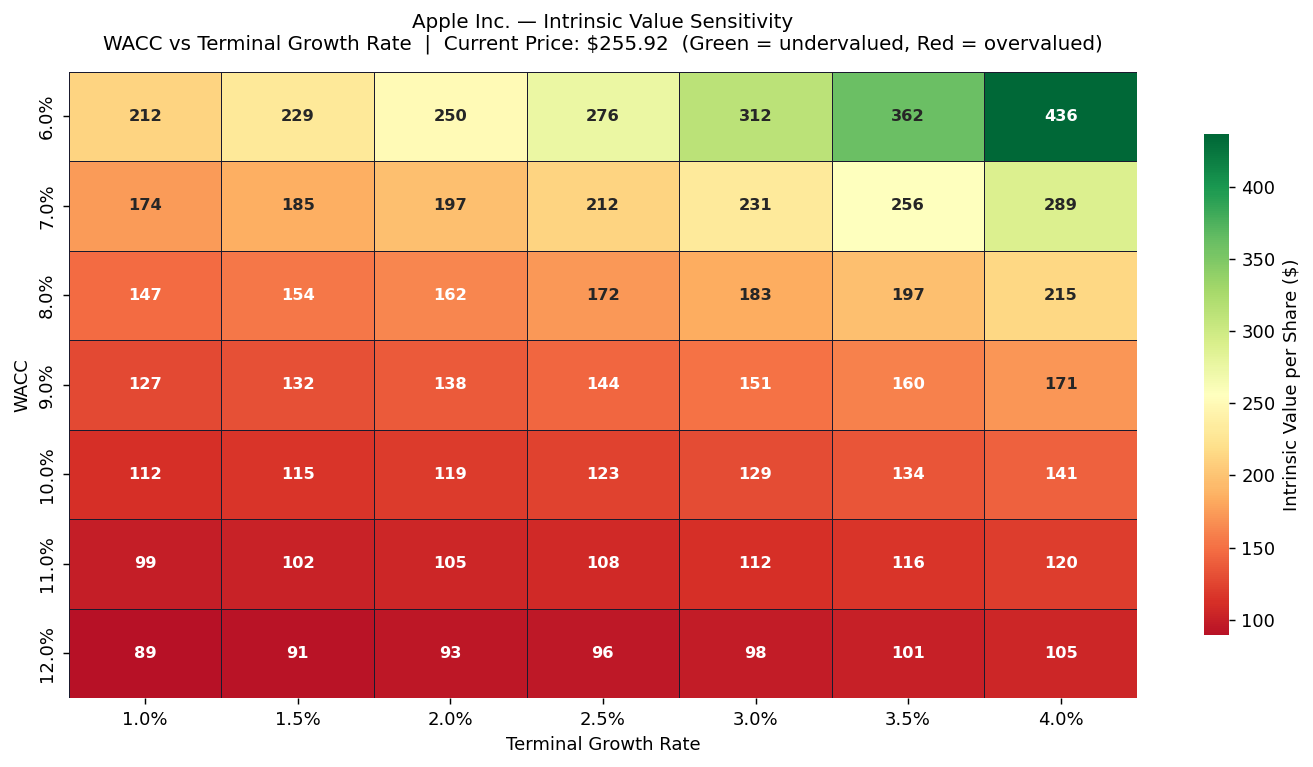

In [84]:
# Sensitivity heatmap
fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(
    sens_matrix.astype(float), annot=True, fmt='.0f',
    mask=sens_matrix.isna(), cmap='RdYlGn', center=current_price,
    linewidths=0.5, linecolor='#1a1a2e',
    annot_kws={'size': 9, 'weight': 'bold'},
    cbar_kws={'label': 'Intrinsic Value per Share ($)', 'shrink': 0.8}, ax=ax
)
ax.set_title(
    f'{company_name} — Intrinsic Value Sensitivity\n'
    f'WACC vs Terminal Growth Rate  |  Current Price: ${current_price:.2f}  '
    f'(Green = undervalued, Red = overvalued)',
    fontsize=11, pad=12
)
ax.set_xlabel('Terminal Growth Rate', fontsize=10)
ax.set_ylabel('WACC', fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

---
## 7. Comparable Company Analysis (Trading Multiples)

In [85]:
def get_multiples(ticker: str) -> dict:
    i = yf.Ticker(ticker).info
    return {
        'Ticker'      : ticker,
        'Name'        : i.get('shortName', ticker),
        'Mkt Cap ($B)': (i.get('marketCap') or 0) / 1e9,
        'EV/EBITDA'   : i.get('enterpriseToEbitda'),
        'EV/Revenue'  : i.get('enterpriseToRevenue'),
        'P/E (TTM)'   : i.get('trailingPE'),
        'P/FCF'       : i.get('priceToFreeCashflows'),
        'Gross Margin': i.get('grossMargins'),
        'FCF Margin'  : i.get('freeCashflowMargin') or ((i.get('freeCashflow') or 0) / (i.get('totalRevenue') or 1)),
        'Rev Growth'  : i.get('revenueGrowth'),
        'Beta'        : i.get('beta'),
    }

print(f'Fetching comps: {[TICKER] + COMPS}...')
comp_rows = []
for t in [TICKER] + COMPS:
    try:
        comp_rows.append(get_multiples(t))
    except Exception as e:
        print(f'  ⚠️  {t}: {e}')

comps_df     = pd.DataFrame(comp_rows).set_index('Ticker')
display_cols = ['Mkt Cap ($B)', 'EV/EBITDA', 'EV/Revenue', 'P/E (TTM)', 'P/FCF',
                'Gross Margin', 'FCF Margin', 'Rev Growth', 'Beta']

display(
    comps_df[display_cols].style
    .format({'Mkt Cap ($B)': '{:.1f}', 'EV/EBITDA': '{:.1f}x', 'EV/Revenue': '{:.2f}x',
             'P/E (TTM)': '{:.1f}x', 'P/FCF': '{:.1f}x',
             'Gross Margin': '{:.1%}', 'FCF Margin': '{:.1%}',
             'Rev Growth': '{:.1%}', 'Beta': '{:.2f}'}, na_rep='N/A')
    .highlight_min(color='#ffd0d0', axis=0, subset=['EV/EBITDA', 'P/E (TTM)', 'P/FCF'])
    .highlight_max(color='#d0ffd0', axis=0, subset=['Gross Margin', 'FCF Margin'])
    .set_caption('Comparable Company Analysis')
    .set_table_styles(TABLE_STYLES)
)

Fetching comps: ['AAPL', 'MSFT', 'GOOGL', 'META', 'AMZN']...


,Mkt Cap ($B),EV/EBITDA,EV/Revenue,P/E (TTM),P/FCF,Gross Margin,FCF Margin,Rev Growth,Beta
Ticker,,,,,,,,,
AAPL,3761.5,24.7x,8.68x,32.4x,N/A,47.3%,24.4%,15.7%,1.11
MSFT,2775.7,16.0x,9.19x,23.4x,N/A,68.6%,17.6%,16.7%,1.11
GOOGL,3577.9,23.4x,8.73x,27.4x,N/A,59.7%,9.5%,18.0%,1.13
META,1453.1,14.3x,7.25x,24.4x,N/A,82.0%,11.7%,23.8%,1.31
AMZN,2251.9,15.8x,3.22x,29.3x,N/A,50.3%,3.3%,13.6%,1.38


In [86]:
# Multiples-implied prices for the target
target_info    = yf.Ticker(TICKER).info
target_ebitda  = target_info.get('ebitda')       or 0
target_revenue = target_info.get('totalRevenue')  or 0
target_eps     = target_info.get('trailingEps')   or 0
target_fcf_sh  = (target_info.get('freeCashflow', 0) / shares_out) if shares_out else 0
target_net_debt= total_debt - cash
peers          = comps_df.drop(index=TICKER, errors='ignore')

def implied_ev(col, metric, net_debt, shares):
    med = peers[col].median()
    return (med * metric - net_debt) / shares if (pd.notna(med) and metric and shares) else np.nan

def implied_eq(col, metric):
    med = peers[col].median()
    return med * metric if pd.notna(med) else np.nan

iv_ev_ebitda = implied_ev('EV/EBITDA',  target_ebitda,  target_net_debt, shares_out)
iv_ev_rev    = implied_ev('EV/Revenue', target_revenue, target_net_debt, shares_out)
iv_pe        = implied_eq('P/E (TTM)',  target_eps)
iv_pfcf      = implied_eq('P/FCF',      target_fcf_sh)

implied_rows = []
for label, val, col in [
    ('EV/EBITDA (peer median)',  iv_ev_ebitda, 'EV/EBITDA'),
    ('EV/Revenue (peer median)', iv_ev_rev,    'EV/Revenue'),
    ('P/E TTM (peer median)',    iv_pe,         'P/E (TTM)'),
    ('P/FCF (peer median)',      iv_pfcf,       'P/FCF'),
]:
    med = peers[col].median() if col in peers.columns else np.nan
    implied_rows.append({
        'Method'             : label,
        'Peer Median Multiple': f'{med:.1f}x' if pd.notna(med) else 'N/A',
        'Implied Price'      : f'${val:.2f}'  if pd.notna(val) else 'N/A',
        'vs Current Price'   : f'{val/current_price-1:+.1%}' if pd.notna(val) else 'N/A',
    })

display(
    pd.DataFrame(implied_rows).set_index('Method').style
    .set_caption(f'{company_name} — Multiples-Implied Prices  |  Current: ${current_price:.2f}')
    .set_table_styles(TABLE_STYLES)
)

,Peer Median Multiple,Implied Price,vs Current Price
Method,,,
EV/EBITDA (peer median),15.9x,$164.24,-35.8%
EV/Revenue (peer median),8.0x,$235.49,-8.0%
P/E TTM (peer median),25.9x,$204.99,-19.9%
P/FCF (peer median),N/A,N/A,N/A


---
## 8. Football Field Chart — Valuation Summary

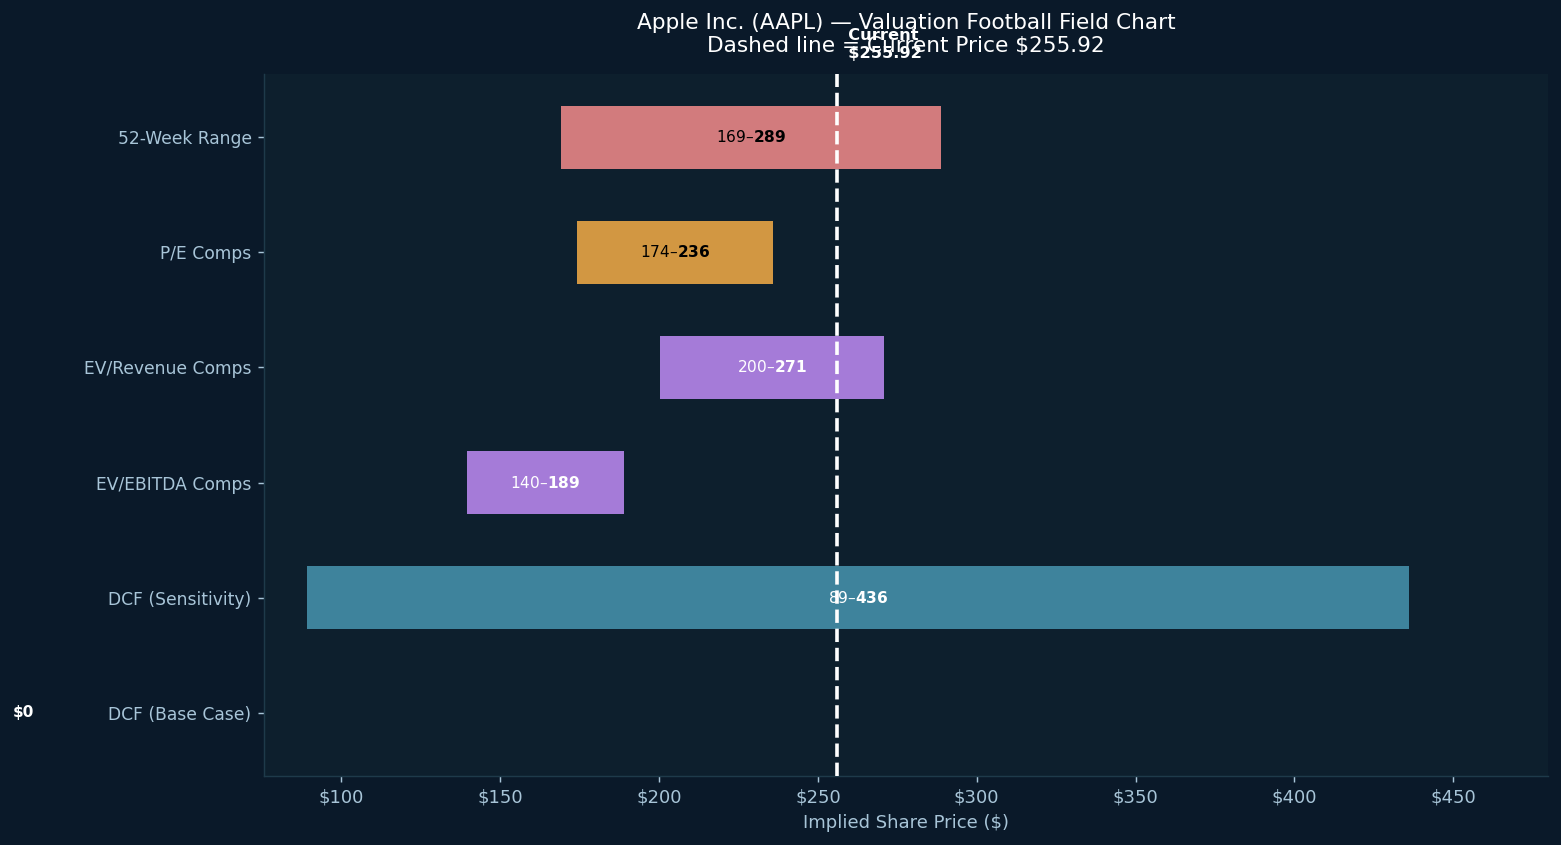

In [87]:
# Collect valuation ranges
ranges = [('DCF (Base Case)', result['per_share'], result['per_share'])]

sens_vals = sens_matrix.values.flatten()
sens_vals = sens_vals[~np.isnan(sens_vals.astype(float))].astype(float)
if len(sens_vals):
    ranges.append(('DCF (Sensitivity)', sens_vals.min(), sens_vals.max()))


for label, val in [('EV/EBITDA Comps', iv_ev_ebitda), ('EV/Revenue Comps', iv_ev_rev), ('P/E Comps', iv_pe)]:
    if pd.notna(val):
        ranges.append((label, val * 0.85, val * 1.15))

w52_lo = target_info.get('fiftyTwoWeekLow',  current_price * 0.8)
w52_hi = target_info.get('fiftyTwoWeekHigh', current_price * 1.2)
ranges.append(('52-Week Range', w52_lo, w52_hi))

COLORS   = ['#00d4aa', '#4a9ab5', '#c890ff', '#c890ff', '#ffb347', '#ff9090', '#7ec8e3', '#888888']
labels   = [r[0] for r in ranges]
lows, highs = [r[1] for r in ranges], [r[2] for r in ranges]
all_vals = [v for v in lows + highs if pd.notna(v) and v > 0]

fig, ax = plt.subplots(figsize=(12, len(ranges) * 0.85 + 1.5))
for i, (label, lo, hi, color) in enumerate(zip(labels, lows, highs, COLORS)):
    lo_v, hi_v = (lo if pd.notna(lo) else 0), (hi if pd.notna(hi) else 0)
    ax.barh(i, max(hi_v - lo_v, 1.0), left=lo_v, height=0.55, color=color, alpha=0.82)
    mid = (lo_v + hi_v) / 2
    ax.text(mid, i,
            f'${lo_v:.0f} – ${hi_v:.0f}' if abs(hi_v - lo_v) > 0.5 else f'${lo_v:.0f}',
            va='center', ha='center', fontsize=8.5, fontweight='bold',
            color='black' if color in ['#ffb347', '#7ec8e3', '#ff9090'] else 'white')

ax.axvline(current_price, color='white', linewidth=2, linestyle='--', zorder=5)
ax.text(current_price, len(ranges) - 0.05, f'  Current\n  ${current_price:.2f}',
        va='top', fontsize=9, color='white', fontweight='bold')

ax.set_yticks(range(len(ranges)))
ax.set_yticklabels(labels, fontsize=9.5)
ax.set_xlabel('Implied Share Price ($)', fontsize=10)
ax.set_xlim(max(0, min(all_vals) * 0.85), max(all_vals) * 1.10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}'))
ax.set_facecolor('#0d1f2d')
fig.patch.set_facecolor('#0a1929')
ax.tick_params(colors='#a8c5d8')
ax.xaxis.label.set_color('#a8c5d8')
ax.spines['bottom'].set_color('#1e3a4a')
ax.spines['left'].set_color('#1e3a4a')
ax.set_title(f'{company_name} ({TICKER}) — Valuation Football Field Chart\nDashed line = Current Price ${current_price:.2f}',
             fontsize=12, pad=12, color='white')
plt.tight_layout()
plt.show()

---
## 9. Final Scorecard

In [88]:
all_implied      = [v for v in [result['per_share'], iv_ev_ebitda, iv_ev_rev, iv_pe]
                    if pd.notna(v) and v > 0]
consensus_val    = np.mean(all_implied)
consensus_upside = (consensus_val / current_price - 1) if current_price else np.nan

for threshold, label in [
    (0.20, '🟢 STRONG BUY    — Significant margin of safety'),
    (0.10, '🟢 BUY           — Trading below intrinsic value'),
    (-0.05,'🟡 FAIRLY VALUED — Within ±10% of consensus'),
    (-0.15,'🔴 SLIGHT SELL   — Modestly overvalued'),
    (-99,  '🔴 SELL          — Significantly overvalued'),
]:
    if consensus_upside >= threshold:
        final_signal = label
        break

rows = [
    ('Current Market Price',      f'${current_price:.2f}',             ''),
    ('DCF Intrinsic Value',       f'${result["per_share"]:.2f}',        f'{result["per_share"]/current_price-1:+.1%}'),
]
if pd.notna(iv_ev_ebitda): rows.append(('EV/EBITDA Comps', f'${iv_ev_ebitda:.2f}', f'{iv_ev_ebitda/current_price-1:+.1%}'))
if pd.notna(iv_pe):        rows.append(('P/E Comps',       f'${iv_pe:.2f}',        f'{iv_pe/current_price-1:+.1%}'))

rows += [
    ('Consensus (avg of methods)', f'${consensus_val:.2f}',  f'{consensus_upside:+.1%}'),
    ('WACC',                       f'{WACC:.2%}',             ''),
    ('Terminal Growth Rate',        f'{TERMINAL_GROWTH:.2%}', ''),
    ('Rating',                      final_signal,             ''),
]

scorecard_df = pd.DataFrame(rows, columns=['Metric', 'Value', 'vs Current']).set_index('Metric')

display(
    scorecard_df.style
    .set_caption(f'{company_name} ({TICKER}) — Final Scorecard')
    .set_table_styles(TABLE_STYLES + [
        {'selector': 'tr:last-child td', 'props': [('font-weight', 'bold'), ('font-size', '13px')]}
    ])
)

print('\n⚠️  DISCLAIMER: This is a quantitative model for educational purposes only. Not financial advice.')

,Value,vs Current
Metric,,
Current Market Price,$255.92,
DCF Intrinsic Value,$nan,+nan%
EV/EBITDA Comps,$164.24,-35.8%
P/E Comps,$204.99,-19.9%
Consensus (avg of methods),$201.57,-21.2%
WACC,nan%,
Terminal Growth Rate,2.50%,
Rating,🔴 SELL — Significantly overvalued,



⚠️  DISCLAIMER: This is a quantitative model for educational purposes only. Not financial advice.
